The main idea of this project is to find out how we can turn written texts into data by looking at patterns in word choice. We can use the text file we were given to look for some unique words or how the words changes between the two authors. Texts vary a lot in length so normalized frequencies can be done. I am choosing Sense and Sensibility + Northanger Abbey by Jane Austen, as well as Moby Dick Or The Whale by Herman Miller for my books.

In [4]:
import re
import nltk
from collections import Counter
import operator

nltk.download('stopwords')

# We may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
    'ut', '\'re', '.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
    '"', '-', '}', '{', '&', '|', u'\u2014'
]

# Remove special characters, quotes, etc. from each word
def cleanWord(w):
    wn = re.sub('[,"\.\'&\|:@>*;/=]', "", w)
    # Get rid of numbers
    return re.sub('^[0-9\.]*$', "", wn)


# Define a function to read text/clean/calculate frequency
def get_wf(filename):

    # Read the local text file
    with open(filename, 'r', encoding='utf-8') as f:
        t = f.read().lower()

    # Split string into an array of words
    wds = re.split('\s+', t)

    # Remove periods, commas, etc. stuck to the edges of words
    for i in range(len(wds)):
        wds[i] = cleanWord(wds[i])

    # Calculate word frequencies
    wf = Counter(wds)

    # Remove stop words from the dictionary
    for k in stop_words:
        wf.pop(k, None)

    # Remove empty strings
    wf.pop('', None)

    # How many regular words in the document?
    tw = 0
    for w in wf:
        tw += wf[w]

    # Get ordered list
    wfs = sorted(
        wf.items(),
        key=operator.itemgetter(1),
        reverse=True
    )

    ml = min(len(wfs), 15)

    # Reverse the list because barh plots items from the bottom
    return (wfs[0:ml][::-1], tw)


# Now use local text files
(wf_ee, tw_ee) = get_wf('Northanger Abbey by Jane Austen.txt')
(wf_bu, tw_bu) = get_wf('Moby Dick Or The Whale by Herman Meville.txt')

<>:16: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:18: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:29: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:16: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:18: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:29: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/fz/npbhwggs3657c90bczn_4jw80000gn/T/ipykernel_50341/1325080685.

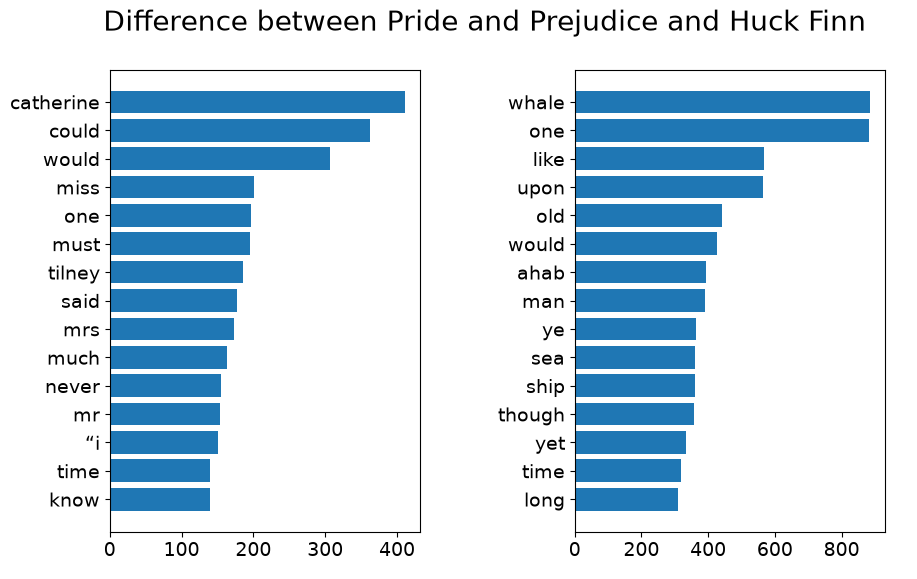

In [ ]:
# Plot the results: are there striking differences in language?

import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline

def plotTwoLists(wf_ee, wf_bu, title):

    f = plt.figure(figsize=(10, 6))

    f.suptitle(title, fontsize=20)

    ax = f.add_subplot(111)

    ax.spines['top'].set_color('none')
    ax.spines['bottom'].set_color('none')
    ax.spines['left'].set_color('none')
    ax.spines['right'].set_color('none')

    ax.tick_params(
        labelcolor='w',
        top=False,
        bottom=False,
        left=False,
        right=False,
        labelsize=20
    )

    # First subplot
    ax1 = f.add_subplot(121)

    plt.subplots_adjust(wspace=0.5)

    ax1.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )

    pos = np.arange(len(wf_ee))

    pylab.yticks(
        pos,
        [x[0] for x in wf_ee]
    )

    ax1.barh(
        range(len(wf_ee)),
        [x[1] for x in wf_ee],
        align='center'
    )

    # Second subplot
    ax2 = f.add_subplot(122)

    ax2.tick_params(
        axis='both',
        which='major',
        labelsize=14
    )

    pos = np.arange(len(wf_bu))

    pylab.yticks(
        pos,
        [x[0] for x in wf_bu]
    )

    ax2.barh(
        range(len(wf_bu)),
        [x[1] for x in wf_bu],
        align='center'
    )

    plt.show()


plotTwoLists(
    wf_ee,
    wf_bu,
    'Difference between Northanger Abbey and Moby Dick Or The Whale'
)
